In [5]:
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


Black Scholes formula implementation

In [4]:
def black_scholes_call(S,K,r,T,sigma):
    d1=(np.log(S/K)+(r+0.5*sigma**2)*T)/(sigma*(np.sqrt(T)))
    d2=d1-np.sqrt(T)*sigma
    call_price=S*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    return call_price

price=black_scholes_call(102,110,0.02,0.5,0.42)
print(price)

9.294775908128095


Text(0.5, 1.0, 'Impact de la volatilite')

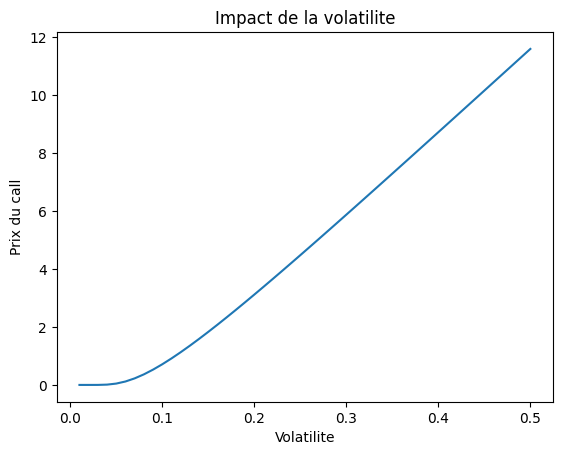

In [13]:
# Analyse de la volatilite
sigmas=np.linspace(0.01,0.5,50)
prices=[black_scholes_call(102,110,0.02,0.5,s) for s in sigmas]

fig,ax=plt.subplots()
ax.plot(sigmas,prices)
ax.set_xlabel('Volatilite')
ax.set_ylabel('Prix du call')
ax.set_title('Impact de la volatilite')

On se rend compte que a mesure que la volatilite augmente le prix du call augmenta aussi. Faisons une analyse pareil avec l'evoluation du temps de maturite.

Text(0.5, 1.0, 'Impact de la volatilite')

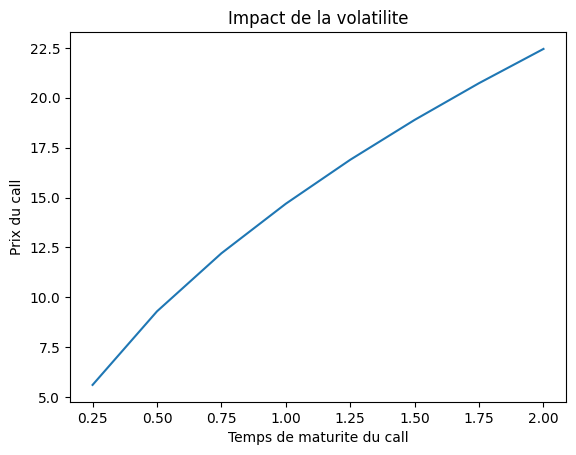

In [17]:
time=np.linspace(0.25,2,8)
prices=[black_scholes_call(102,110,0.02,t,0.42) for t in time]

fig,ax=plt.subplots()
ax.plot(time,prices)
ax.set_xlabel('Temps de maturite du call')
ax.set_ylabel('Prix du call')
ax.set_title('Impact de la volatilite')

Le prix augmente aussi avec le temps.

In [ ]:
def monte_carlo_call(S, K, T, r, sigma, n_sim=10000):
     Z = np.random.normal(0, 1, n_sim) 
     ST = S * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z) 
     payoff = np.maximum(ST - K, 0) 
     return np.exp(-r*T) * np.mean(payoff) 

Prix Monte Carlo : 9.068575199750718


In [20]:
mc_price = monte_carlo_call(102,110,0.5,0.02,0.42)
price=black_scholes_call(102,110,0.02,0.5,0.42)
print("Black-Scholes :", price)
print("Monte Carlo  :", mc_price)

Black-Scholes : 9.294775908128095
Monte Carlo  : 9.302163851677898
